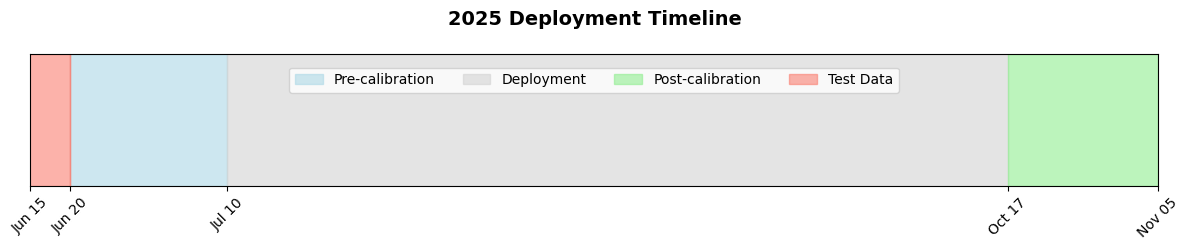

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ------------------------------
# Load deployment date data
# ------------------------------
date_file = r"../reference_files/2025_deployment_dates.xlsx"
sensor_id = "TerraBella"

df_dates = pd.read_excel(date_file, sheet_name=1)
row = df_dates.loc[df_dates['sensor_id'] == sensor_id].squeeze()

# Convert date columns to datetime
date_columns = [c for c in df_dates.columns 
                if c not in ['sensor_id', 'PreNumDays', 'PostNumDays', 'WithFEM']]
row[date_columns] = pd.to_datetime(row[date_columns])

# ------------------------------
# Define deployment periods
# ------------------------------

# Derived deployment window (between end of pre-cal and start of post-cal)
deployment_start = row['newpreend']
deployment_end   = row['newpoststart']

periods = [
    (row['newprestart'], row['newpreend'], "Pre-calibration"),
    (deployment_start, deployment_end, "Deployment"),          # NEW
    (row['newpoststart'], row['newpostend'], "Post-calibration"),
    (row['Trial1Start'], row['Trial1End'], "Test Data"),
    (row['Trial2Start'], row['Trial2End'], "Test Data")
]

# ------------------------------
# Color map (add Deployment)
# ------------------------------
label_to_color = {
    "Pre-calibration": "lightblue",
    "Deployment": "lightgray",        # NEW
    "Post-calibration": "lightgreen",
    "Test Data": "salmon",
    "Other": "lightgray"
}
# ------------------------------
# Plot timeline
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 2.5))
fig.suptitle("2025 Deployment Timeline", fontsize=14, fontweight = 'bold')

# Draw colored spans
used_labels = set()
for p_start, p_end, label in periods:
    ax.axvspan(p_start, p_end,
               color=label_to_color[label],
               alpha=0.6,
               label=label if label not in used_labels else "")
    used_labels.add(label)

# ------------------------------
# X-axis ticks: monthly + endpoints
# ------------------------------

timeline_start = pd.to_datetime("2025-06-15")
timeline_end = pd.to_datetime("2025-11-05")
month_starts = pd.date_range(
    start=timeline_start.replace(day=1),
    end=timeline_end,
    freq='MS'
)

tick_dates = [timeline_start]

for p_start, p_end, label in periods:
    tick_dates.append(pd.to_datetime(p_start))
    tick_dates.append(pd.to_datetime(p_end))

# Remove duplicates and sort
tick_dates = sorted(set(tick_dates))

ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Remove y-axis (not needed)
ax.set_yticks([])

# Legend
ax.legend(loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.95))
ax.set_xlim(timeline_start,timeline_end)
plt.xticks(rotation=45)

# Tight layout and save
plt.tight_layout()
plt.savefig(r"../../PlotsForRubenNov25/timeline.jpg",
            format='jpg', dpi=300)
plt.show()
